In [ ]:
!pip install transformers sentencepiece wandb -q

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import T5Tokenizer, T5ForConditionalGeneration
from tqdm.auto import tqdm
import wandb
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
wandb.login(key='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')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: perlamargaritka (vitalyansky-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# беру t5-small, это маленькая претрейн моделька, которую я буду дообучать под ретеншен ответы
model_name = 't5-small'
model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)
toke = T5Tokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

In [ ]:
# считаем сколько параметров в каждой части модели(энкодер, декодер и сколко всего)
def count_params(module):
    return sum(p.numel() for p in module.parameters())
print('эмбеддинги', count_params(model.shared))
print('энкондер', count_params(model.encoder))
print('декодер', count_params(model.decoder))
print('всего парам', count_params(model))

эмбеддинги 16449536
энкондер 35330816
декодер 41625344
всего парам 60506624


In [ ]:
from openpyxl import load_workbook
import io

wb = load_workbook('retention_dialog.xlsx', read_only=True)
ws = wb.active
rows = [row[0] for row in ws.iter_rows(values_only=True) if row[0]]
data = pd.read_csv(io.StringIO('\n'.join(rows)), on_bad_lines='skip')
data = data[data['source'].isin(['twitter', 'bitext'])].reset_index(drop=True)
data.shape

(5620, 3)

In [ ]:
# параметры обучения(общие для всех тестов)
max_input_len = 128
max_target_len = 128
batch_size = 8
epoch = 3
lr = 3e-4

In [ ]:
class Base(Dataset):
  def __init__(self, row, tokenizer):
    self.inputs = row.input_text.reset_index(drop=True)
    self.targets = row.target_text.reset_index(drop=True)
    self.tokenizer = tokenizer
  def __len__(self):
    return len(self.inputs)
  def __getitem__(self, ind):
    inputs = self.tokenizer('reply as support agent: ' + self.inputs[ind],
                            max_length=max_input_len, padding='max_length',
                            truncation=True, return_tensors='pt')
    targets = self.tokenizer(self.targets[ind], max_length=max_target_len,
                             padding='max_length', truncation=True, return_tensors='pt')
    labels = targets['input_ids'].squeeze()
    labels[labels == self.tokenizer.pad_token_id] = -100
    return {'input_ids':inputs['input_ids'].squeeze(),
            'attention_mask':inputs['attention_mask'].squeeze(),
            'labels':labels}

In [ ]:
# val loss на сэмпле чем ниже, тем точнее модель предсказывает токены
def get_loss(model, toke, df, n=50):
    sample = df.sample(min(n, len(df)), random_state=42).reset_index(drop=True)
    acc = 0
    with torch.no_grad():
        for ind in range(len(sample)):
            inputs = toke('reply as support agent: ' + sample.input_text[ind],
                           max_length=max_input_len, padding='max_length',
                           truncation=True, return_tensors='pt').to(device)
            targets = toke(sample.target_text[ind], max_length=max_target_len,
                            padding='max_length', truncation=True, return_tensors='pt').to(device)
            labels = targets['input_ids'].clone()
            labels[labels == toke.pad_token_id] = -100
            out = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'], labels=labels)
            acc += out.loss.item()
    return round(acc / len(sample), 3)

In [ ]:
# модель для семант схожести,я сравниваю смысл ответа модели и эталона
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

sim_tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
sim_model = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2').to(device)
sim_model.eval()

def get_embedding(texts):
    inputs = sim_tokenizer(texts, padding=True, truncation=True, return_tensors='pt').to(device)
    with torch.no_grad():
        out = sim_model(**inputs)
    return out.last_hidden_state.mean(dim=1)

def gen_responses(model, toke, df):
    responses = []
    with torch.no_grad():
        for ind in range(len(df)):
            inp = toke('reply as support agent: ' + df.input_text[ind],
                        return_tensors='pt', max_length=max_input_len, truncation=True).to(device)
            out = model.generate(inp['input_ids'], max_new_tokens=64, num_beams=4, early_stopping=True)
            responses.append(toke.decode(out[0], skip_special_tokens=True))
    return responses

def get_semantic_similarity(preds, references):
    emb_preds = get_embedding(preds)
    emb_refs = get_embedding(references)
    return round(F.cosine_similarity(emb_preds, emb_refs).mean().item(), 3)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

я взяла след метрики для прогонов: 1) val loss(ошибка на валидации), считаю как кросс энтропию. метрика показывает насколько точно модель предсказывает токены таргетного ответа(чем ниже - тем лучше)
2) семантическая блиость = косинус сходство эмбеддингов ответа модели и таргета (от -1 до 1). показывает близость слов
3) distinct-2(https://arya.ai/blog/llm-evaluation-metrics) — доля уникальных биграмм среди всех ответов (от 0 до 1). так я смогу увидеть, что у модели низкое разнообразие в ответах

In [ ]:
def distinct2(texts):
    bigrams = []
    for t in texts:
        words = t.lower().split()
        bigrams += list(zip(words[:-1], words[1:]))
    if not bigrams:
        return 0.0
    return round(len(set(bigrams)) / len(bigrams), 3)

In [ ]:
def run_training(train_df, val_df, run_name, dataset_size_tag, lr, epoch, freeze_mode='full'):
    model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)
    toke = T5Tokenizer.from_pretrained(model_name)

    # full - всё обучается, decoder_only - только decoder+lm_head, top_layers - последние 2 блока decoder
    if freeze_mode == 'decoder_only':
        for p in model.encoder.parameters(): p.requires_grad = False
        for p in model.shared.parameters(): p.requires_grad = False
    elif freeze_mode == 'top_layers':
        for p in model.parameters(): p.requires_grad = False
        for p in model.decoder.block[-2:].parameters(): p.requires_grad = True
        for p in model.lm_head.parameters(): p.requires_grad = True
    train_loader = DataLoader(Base(train_df, toke), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Base(val_df, toke), batch_size=batch_size, shuffle=False)
    run = wandb.init(entity='martyanov-an-', project='GP_5', name=run_name,
        config={'model': model_name, 'freeze_mode': freeze_mode, 'lr': lr, 'epoch': epoch,
                'train_rows': len(train_df), 'val_rows': len(val_df)})
    model.eval()
    loss_before = get_loss(model, toke, val_df)
    eval_s = val_df.sample(min(20, len(val_df)), random_state=42).reset_index(drop=True)
    refs = eval_s.target_text.tolist()
    preds_before = gen_responses(model, toke, eval_s)
    sim_before = get_semantic_similarity(preds_before, refs)
    d2_before = distinct2(preds_before)
    print(f'до: loss={loss_before} sim={sim_before} distinct2={d2_before}')
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    train_loss, val_loss = [], []
    for i in range(epoch):
        model.train()
        el = 0
        for item in tqdm(train_loader):
            ids = item['input_ids'].to(device)
            mask = item['attention_mask'].to(device)
            labels = item['labels'].to(device)
            optim.zero_grad()
            out = model(input_ids=ids, attention_mask=mask, labels=labels)
            out.loss.backward()
            optim.step()
            el += out.loss.item()
        el = round(el / len(train_loader), 3)
        train_loss.append(el)
        model.eval()
        vl = 0
        with torch.no_grad():
            for item in tqdm(val_loader):
                ids = item['input_ids'].to(device)
                mask = item['attention_mask'].to(device)
                labels = item['labels'].to(device)
                out = model(input_ids=ids, attention_mask=mask, labels=labels)
                vl += out.loss.item()
        vl = round(vl / len(val_loader), 3)
        val_loss.append(vl)
        run.log({'epoch': i+1, 'train_loss': el, 'val_loss': vl})
        print(f'epoch {i+1}: train={el} val={vl}')
    model.eval()
    loss_after = get_loss(model, toke, val_df)
    preds_after = gen_responses(model, toke, eval_s)
    sim_after = get_semantic_similarity(preds_after, refs)
    d2_after = distinct2(preds_after)
    print(f'после: loss={loss_after} sim={sim_after} distinct2={d2_after}')
    run.log({'loss_before': loss_before, 'loss_after': loss_after,
             'sim_before': sim_before, 'sim_after': sim_after,
             'd2_before': d2_before, 'd2_after': d2_after})
    save_path = f't5_{dataset_size_tag}'
    model.save_pretrained(save_path)
    toke.save_pretrained(save_path)
    run.log_model(path=save_path, name=save_path)
    run.finish()
    return {'train_loss': train_loss, 'val_loss': val_loss,
            'loss_before': loss_before, 'loss_after': loss_after,
            'sim_before': sim_before, 'sim_after': sim_after,
            'd2_before': d2_before, 'd2_after': d2_after,
            'model': model, 'toke': toke, 'preds_after': preds_after, 'refs': refs}


In [ ]:
# чистка для полной даты, потому что был кейс, что н вске убрали типа nan
data = data.dropna(subset=['input_text', 'target_text'])
data['input_text'] = data['input_text'].astype(str)
data['target_text'] = data['target_text'].astype(str)
data = data.reset_index(drop=True)
data.shape

(5620, 3)

In [ ]:
# берем 1000 строк(это для проверки пайлплайн)
sample = data.sample(n=1000, random_state=42).reset_index(drop=True)
split = int(len(sample) * 0.8)
train_sample = sample[:split].reset_index(drop=True)
val_sample = sample[split:].reset_index(drop=True)
train_sample.shape, val_sample.shape #размер train и val

((800, 3), (200, 3))

In [ ]:
# запуск на сэмпле, логируется как sample_1000
result_sample = run_training(train_sample, val_sample,
    run_name='sample_1000', dataset_size_tag='sample', lr=3e-4, epoch=3)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

до: loss=4.557 sim=0.466 distinct2=0.851


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

epoch 1: train=3.624 val=3.047


...

  0%|          | 0/25 [00:00<?, ?it/s]

epoch 3: train=2.89 val=2.848
после: loss=2.8 sim=0.346 distinct2=0.081


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_sample)... Done. 7.1s


d2_after,▁
d2_before,▁
epoch,▁▅█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▃▁
val_loss,█▄▁
d2_after,0.081
d2_before,0.851


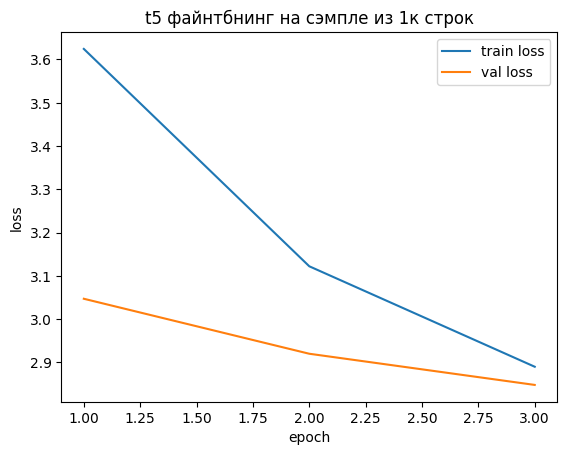

In [ ]:
# train loss должен падать, val loss смотрим не растет ли переобучение
plt.plot(range(1, epoch+1), result_sample['train_loss'], label='train loss')
plt.plot(range(1, epoch+1), result_sample['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('t5 файнтбнинг на сэмпле из 1к строк')
plt.legend()
plt.show()

In [ ]:
# берем весь датасет
full = data.sample(frac=1, random_state=42).reset_index(drop=True)
split = int(len(full) * 0.8)
train_full = full[:split].reset_index(drop=True)
val_full = full[split:].reset_index(drop=True)
train_full.shape, val_full.shape #размеры траейн и валид

((4496, 3), (1124, 3))

In [ ]:
# запуск на полном датасете, логируется как full_dataset
result_full = run_training(train_full, val_full,
    run_name='full_dataset', dataset_size_tag='full', lr=3e-4, epoch=3)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

до: loss=4.507 sim=0.423 distinct2=0.863


  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/141 [00:00<?, ?it/s]

epoch 1: train=3.141 val=2.743


...

  0%|          | 0/141 [00:00<?, ?it/s]

epoch 3: train=2.569 val=2.536
после: loss=2.728 sim=0.533 distinct2=0.164


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_full)... Done. 1.3s


d2_after,▁
d2_before,▁
epoch,▁▅█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▃▁
val_loss,█▃▁
d2_after,0.164
d2_before,0.863


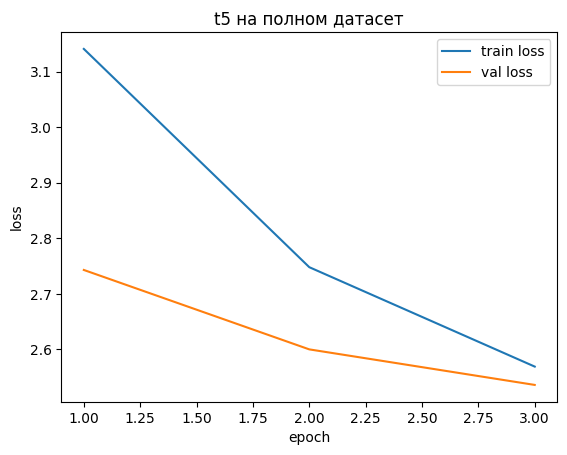

In [ ]:
# тот же график для полного датасета
plt.plot(range(1, epoch+1), result_full['train_loss'], label='train loss')
plt.plot(range(1, epoch+1), result_full['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('t5 на полном датасет')
plt.legend()
plt.show()

In [ ]:
# сравниваем сэмпл и полный датасет по всем метрикам
summary = pd.DataFrame({
    'metric': ['train_rows', 'val_loss_final', 'decoder_loss_before', 'decoder_loss_after',
               'semantic_similarity_before', 'semantic_similarity_after'],
    'sample_1000': [
        len(train_sample),
        result_sample['val_loss'][-1],
        result_sample['loss_before'],
        result_sample['loss_after'],
        result_sample['sim_before'],
        result_sample['sim_after'],
    ],
    'full_dataset': [
        len(train_full),
        result_full['val_loss'][-1],
        result_full['loss_before'],
        result_full['loss_after'],
        result_full['sim_before'],
        result_full['sim_after'],
    ],
})
summary

,metric,sample_1000,full_dataset
0,train_rows,800.000,4496.000
1,val_loss_final,2.848,2.536
2,decoder_loss_before,4.557,4.507
3,decoder_loss_after,2.800,2.728
4,semantic_similarity_before,0.466,0.423
5,semantic_similarity_after,0.346,0.533


In [ ]:
# # смотрим конкретные ответы модели на одних и тех же клиентских сообщениях
# for i in range(5):
#     print('клиент:', result_full['references'][i] if False else val_full.input_text[i])
#     print('ответ (сэмпл):', result_sample['preds_after'][i] if i < len(result_sample['preds_after']) else '-')
#     print('ответ (полный):', result_full['preds_after'][i] if i < len(result_full['preds_after']) else '-')
#     print('эталон:', result_full['references'][i])
#     print()

теперь я буду смотреть разные архитектуры с разными гиперпараметрами, у меня есть варианты lr: 1e-4, 3e-4, 5e-4 при epoch=5(выбрала ее, чтобы относительно норм обучение прошло). сначала буду искать лучший lr для каждой архитектуры, потом сравниваем архитектуры между собой относительно вводы клиента и реакции модели на него

архитектура 1: полный файнтюнинг(обучаются все параметры)

при lr=1e-4, epoch=5

In [ ]:
full_lr1 = run_training(train_full, val_full,
    run_name='full_lr1e4_ep5', dataset_size_tag='full_lr1',
    lr=1e-4, epoch=5, freeze_mode='full')
full_lr1['sim_after'], full_lr1['d2_after']

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

до: loss=4.507 sim=0.423 distinct2=0.863


  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/141 [00:00<?, ?it/s]

epoch 1: train=3.375 val=2.912


...

epoch 5: train=2.653 val=2.597
после: loss=2.801 sim=0.426 distinct2=0.143


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_full_lr1)... Done. 4.5s


d2_after,▁
d2_before,▁
epoch,▁▃▅▆█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▄▃▂▁
val_loss,█▅▃▂▁
d2_after,0.143
d2_before,0.863


(0.426, 0.143)

lr=3e-4, epoch=5

In [ ]:
full_lr3 = run_training(train_full, val_full,
    run_name='full_lr3e4_ep5', dataset_size_tag='full_lr3',
    lr=3e-4, epoch=5, freeze_mode='full')
full_lr3['sim_after'], full_lr3['d2_after']

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

до: loss=4.507 sim=0.423 distinct2=0.863


  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/141 [00:00<?, ?it/s]

epoch 1: train=3.15 val=2.737


...

epoch 5: train=2.33 val=2.476
после: loss=2.674 sim=0.537 distinct2=0.211


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_full_lr3)... Done. 1.6s


d2_after,▁
d2_before,▁
epoch,▁▃▅▆█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▅▃▂▁
val_loss,█▅▃▂▁
d2_after,0.211
d2_before,0.863


(0.537, 0.211)

lr=5e-4, epoch=5

In [ ]:
full_lr5 = run_training(train_full, val_full,
    run_name='full_lr5e4_ep5', dataset_size_tag='full_lr5',
    lr=5e-4, epoch=5, freeze_mode='full')
full_lr5['sim_after'], full_lr5['d2_after']

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

до: loss=4.507 sim=0.423 distinct2=0.863


  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/141 [00:00<?, ?it/s]

epoch 1: train=3.067 val=2.68


...

epoch 5: train=2.168 val=2.454
после: loss=2.63 sim=0.55 distinct2=0.216


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_full_lr5)... Done. 10.6s


d2_after,▁
d2_before,▁
epoch,▁▃▅▆█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▅▃▂▁
val_loss,█▄▂▁▁
d2_after,0.216
d2_before,0.863


(0.55, 0.216)

In [ ]:
full_table = pd.DataFrame([
    {'lr': 1e-4, 'val_loss': full_lr1['val_loss'][-1], 'sim_after': full_lr1['sim_after'], 'd2_after': full_lr1['d2_after']},
    {'lr': 3e-4, 'val_loss': full_lr3['val_loss'][-1], 'sim_after': full_lr3['sim_after'], 'd2_after': full_lr3['d2_after']},
    {'lr': 5e-4, 'val_loss': full_lr5['val_loss'][-1], 'sim_after': full_lr5['sim_after'], 'd2_after': full_lr5['d2_after']},
])
full_table

,lr,val_loss,sim_after,d2_after
0,0.0001,2.597,0.426,0.143
1,0.0003,2.476,0.537,0.211
2,0.0005,2.454,0.550,0.216


In [ ]:
best_full = max([full_lr1, full_lr3, full_lr5], key=lambda r: r['sim_after'])

архитектура 2: обучене декодера(энкодер заморожен)

lr=1e-4, epoch=5

In [ ]:
dec_lr1 = run_training(train_full, val_full,
    run_name='dec_lr1e4_ep5', dataset_size_tag='dec_lr1',
    lr=1e-4, epoch=5, freeze_mode='decoder_only')
dec_lr1['sim_after'], dec_lr1['d2_after']

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

до: loss=4.507 sim=0.423 distinct2=0.863


  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/141 [00:00<?, ?it/s]

epoch 1: train=3.523 val=2.984


...

epoch 5: train=2.768 val=2.668
после: loss=2.867 sim=0.448 distinct2=0.116


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_dec_lr1)... Done. 2.3s


d2_after,▁
d2_before,▁
epoch,▁▃▅▆█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▄▃▂▁
val_loss,█▅▃▂▁
d2_after,0.116
d2_before,0.863


(0.448, 0.116)

lr=3e-4, epoch=5

In [ ]:
dec_lr3 = run_training(train_full, val_full,
    run_name='dec_lr3e4_ep5', dataset_size_tag='dec_lr3',
    lr=3e-4, epoch=5, freeze_mode='decoder_only')
dec_lr3['sim_after'], dec_lr3['d2_after']

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

до: loss=4.507 sim=0.423 distinct2=0.863


  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/141 [00:00<?, ?it/s]

epoch 1: train=3.258 val=2.8


...

epoch 5: train=2.456 val=2.54
после: loss=2.732 sim=0.444 distinct2=0.144


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_dec_lr3)... Done. 4.5s


d2_after,▁
d2_before,▁
epoch,▁▃▅▆█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▄▃▂▁
val_loss,█▅▃▂▁
d2_after,0.144
d2_before,0.863


(0.444, 0.144)

lr=5e-4, epoch=5

In [30]:
dec_lr5 = run_training(train_full, val_full,
    run_name='dec_lr5e4_ep5', dataset_size_tag='dec_lr5',
    lr=5e-4, epoch=5, freeze_mode='decoder_only')
dec_lr5['sim_after'], dec_lr5['d2_after']

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

epoch,▁█
train_loss,█▁
val_loss,█▁
epoch,2
train_loss,2.755
val_loss,2.616


до: loss=4.507 sim=0.423 distinct2=0.863


  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/141 [00:00<?, ?it/s]

...

epoch 5: train=2.322 val=2.509
после: loss=2.694 sim=0.448 distinct2=0.119


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_dec_lr5)... Done. 2.0s


d2_after,▁
d2_before,▁
epoch,▁▃▅▆█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▅▃▂▁
val_loss,█▅▂▂▁
d2_after,0.119
d2_before,0.863


(0.448, 0.119)

In [31]:
dec_table = pd.DataFrame([
    {'lr': 1e-4, 'val_loss': dec_lr1['val_loss'][-1], 'sim_after': dec_lr1['sim_after'], 'd2_after': dec_lr1['d2_after']},
    {'lr': 3e-4, 'val_loss': dec_lr3['val_loss'][-1], 'sim_after': dec_lr3['sim_after'], 'd2_after': dec_lr3['d2_after']},
    {'lr': 5e-4, 'val_loss': dec_lr5['val_loss'][-1], 'sim_after': dec_lr5['sim_after'], 'd2_after': dec_lr5['d2_after']},
])
dec_table

,lr,val_loss,sim_after,d2_after
0,0.0001,2.668,0.448,0.116
1,0.0003,2.540,0.444,0.144
2,0.0005,2.509,0.448,0.119


In [43]:
best_dec = max([dec_lr1, dec_lr3, dec_lr5], key=lambda r: r['sim_after'])
best_dec

{'train_loss': [3.523, 3.101, 2.958, 2.85, 2.768],
 'val_loss': [2.984, 2.844, 2.764, 2.706, 2.668],
 'loss_before': 4.507,
 'loss_after': 2.867,
 'sim_before': 0.423,
 'sim_after': 0.448,
 'd2_before': 0.863,
 'd2_after': 0.116,
 'model': T5ForConditionalGeneration(
   (shared): Embedding(32128, 512)
   (encoder): T5Stack(
     (embed_tokens): Embedding(32128, 512)
     (block): ModuleList(
       (0): T5Block(
         (layer): ModuleList(
           (0): T5LayerSelfAttention(
             (SelfAttention): T5Attention(
               (q): Linear(in_features=512, out_features=512, bias=False)
               (k): Linear(in_features=512, out_features=512, bias=False)
               (v): Linear(in_features=512, out_features=512, bias=False)
               (o): Linear(in_features=512, out_features=512, bias=False)
               (relative_attention_bias): Embedding(32, 8)
             )
             (layer_norm): T5LayerNorm()
             (dropout): Dropout(p=0.1, inplace=False)
        

архитектура 3: топ слои (заморожено все, кроме последних 2 блоков декодера)

lr=1e-4, epoch=5

In [33]:
top_lr1 = run_training(train_full, val_full,
    run_name='top_lr1e4_ep3', dataset_size_tag='top_lr1',
    lr=1e-4, epoch=5, freeze_mode='top_layers')
top_lr1['sim_after'], top_lr1['d2_after']

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

до: loss=4.507 sim=0.423 distinct2=0.863


  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/141 [00:00<?, ?it/s]

epoch 1: train=3.934 val=3.29


...

epoch 5: train=3.206 val=2.934
после: loss=3.122 sim=0.454 distinct2=0.153


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_top_lr1)... Done. 6.9s


d2_after,▁
d2_before,▁
epoch,▁▃▅▆█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▄▃▂▁
val_loss,█▅▃▂▁
d2_after,0.153
d2_before,0.863


(0.454, 0.153)

lr=3e-4, epoch=3

In [34]:
top_lr3 = run_training(train_full, val_full,
    run_name='top_lr3e4_ep3', dataset_size_tag='top_lr3',
    lr=3e-4, epoch=3, freeze_mode='top_layers')
top_lr3['sim_after'], top_lr3['d2_after']

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

до: loss=4.507 sim=0.423 distinct2=0.863


  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/141 [00:00<?, ?it/s]

epoch 1: train=3.643 val=3.064


...

epoch 5: train=2.904 val=2.746
после: loss=2.946 sim=0.46 distinct2=0.148


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_top_lr3)... Done. 4.8s


d2_after,▁
d2_before,▁
epoch,▁▃▅▆█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▄▃▂▁
val_loss,█▅▃▂▁
d2_after,0.148
d2_before,0.863


(0.46, 0.148)

lr=5e-4, epoch=3

In [35]:
top_lr5 = run_training(train_full, val_full,
    run_name='top_lr5e4_ep3', dataset_size_tag='top_lr5',
    lr=5e-4, epoch=3, freeze_mode='top_layers')
top_lr5['sim_after'], top_lr5['d2_after']

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

до: loss=4.507 sim=0.423 distinct2=0.863


  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/141 [00:00<?, ?it/s]

epoch 1: train=3.526 val=2.975


...

epoch 5: train=2.759 val=2.671
после: loss=2.854 sim=0.412 distinct2=0.145


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (t5_top_lr5)... Done. 5.1s


d2_after,▁
d2_before,▁
epoch,▁▃▅▆█
loss_after,▁
loss_before,▁
sim_after,▁
sim_before,▁
train_loss,█▄▃▂▁
val_loss,█▅▃▂▁
d2_after,0.145
d2_before,0.863


(0.412, 0.145)

In [36]:
top_table = pd.DataFrame([
    {'lr': 1e-4, 'val_loss': top_lr1['val_loss'][-1], 'sim_after': top_lr1['sim_after'], 'd2_after': top_lr1['d2_after']},
    {'lr': 3e-4, 'val_loss': top_lr3['val_loss'][-1], 'sim_after': top_lr3['sim_after'], 'd2_after': top_lr3['d2_after']},
    {'lr': 5e-4, 'val_loss': top_lr5['val_loss'][-1], 'sim_after': top_lr5['sim_after'], 'd2_after': top_lr5['d2_after']},
])
top_table

,lr,val_loss,sim_after,d2_after
0,0.0001,2.934,0.454,0.153
1,0.0003,2.746,0.460,0.148
2,0.0005,2.671,0.412,0.145


In [45]:
best_top = max([top_lr1, top_lr3, top_lr5], key=lambda r: r['sim_after'])
best_top

{'train_loss': [3.643, 3.249, 3.095, 2.988, 2.904],
 'val_loss': [3.064, 2.92, 2.84, 2.782, 2.746],
 'loss_before': 4.507,
 'loss_after': 2.946,
 'sim_before': 0.423,
 'sim_after': 0.46,
 'd2_before': 0.863,
 'd2_after': 0.148,
 'model': T5ForConditionalGeneration(
   (shared): Embedding(32128, 512)
   (encoder): T5Stack(
     (embed_tokens): Embedding(32128, 512)
     (block): ModuleList(
       (0): T5Block(
         (layer): ModuleList(
           (0): T5LayerSelfAttention(
             (SelfAttention): T5Attention(
               (q): Linear(in_features=512, out_features=512, bias=False)
               (k): Linear(in_features=512, out_features=512, bias=False)
               (v): Linear(in_features=512, out_features=512, bias=False)
               (o): Linear(in_features=512, out_features=512, bias=False)
               (relative_attention_bias): Embedding(32, 8)
             )
             (layer_norm): T5LayerNorm()
             (dropout): Dropout(p=0.1, inplace=False)
          

итоговоег сравнение лучших результатов архитектур

In [46]:
arch_table = pd.DataFrame([
    {'arch': 'full fine-tuning', 'val_loss': best_full['val_loss'][-1], 'sim_after': best_full['sim_after'], 'd2_after': best_full['d2_after']},
    {'arch': 'decoder only', 'val_loss': best_dec['val_loss'][-1],  'sim_after': best_dec['sim_after'],  'd2_after': best_dec['d2_after']},
    {'arch': 'top layers','val_loss': best_top['val_loss'][-1],  'sim_after': best_top['sim_after'],  'd2_after': best_top['d2_after']},
])
arch_table

,arch,val_loss,sim_after,d2_after
0,full fine-tuning,2.454,0.550,0.216
1,decoder only,2.668,0.448,0.116
2,top layers,2.746,0.460,0.148


генерация на лучшей архитектуре с параметами

In [47]:
best_overall = max([best_full, best_dec, best_top], key=lambda r: r['sim_after'])
best_model = best_overall['model'].eval()
best_toke = best_overall['toke']

In [48]:
test_inputs = [
    'I want to cancel my subscription',
    'Your service is too expensive',
    'I found a better deal with a competitor',
    'I am very disappointed with your service',
    'I have been a customer for 2 years but I am leaving',
]

In [49]:
for text in test_inputs:
    inp = best_toke('reply as support agent: ' + text,
                    return_tensors='pt', max_length=128, truncation=True).to(device)
    with torch.no_grad():
        out = best_model.generate(inp['input_ids'], max_new_tokens=64, num_beams=4, early_stopping=True)
    print('клиент:', text)
    print('модель:', best_toke.decode(out[0], skip_special_tokens=True))
    print()

клиент: I want to cancel my subscription
модель: We're here to help! Send us a DM with your email address so we can assist.

клиент: Your service is too expensive
модель: I'm sorry for the trouble! Please send us a DM with your email address so we can connect.

клиент: I found a better deal with a competitor
модель: We're here to help! Send us a DM with your email address so we can connect.

клиент: I am very disappointed with your service
модель: We're sorry to hear this. Please send us a DM with your email address so we can connect.

клиент: I have been a customer for 2 years but I am leaving
модель: We're here to help! Send us a DM with your email address so we can connect.

